<a href="https://colab.research.google.com/github/AshrfCode/Data-Mining-and-Machine-Learning/blob/main/lab5_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_blobs

In [ ]:
# Plot the model data with colored labels

def plotData(data, labels,fNames=["feature1","feature2"],col1=0,col2=1,title="Data set",show=True):
    #plot the titles
    plt.title(title)
    plt.xlabel(fNames[col1])
    plt.ylabel(fNames[col2])
    # plot the data with different color for every label and size of 50 pixels
    myPlot = plt.scatter(data[:,col1],data[:,col2],c = labels, s=50)
    plt.legend(handles=myPlot.legend_elements()[0], labels=list(set(labels)))
    if show == True:
        plt.show()

In [ ]:
def plotTree(Dtree,data,labels,fNames=["feature1","feature2"]):
    tree.plot_tree(Dtree,feature_names=fNames,filled=True)
    plt.show()
    # display tree boundaries
    DecisionBoundaryDisplay.from_estimator(Dtree, data,
            cmap=plt.cm.RdYlBu, response_method="predict",
            xlabel=fNames[0],ylabel=fNames[1])
    plotData(data, labels,fNames,0,1,"tree boundaries",show=False)
    plt.show()

In [ ]:
Iris = load_iris()

data = Iris.data[:, 2:] # petal length and width
trueLabels = Iris.target
fNames = Iris.feature_names[2:]

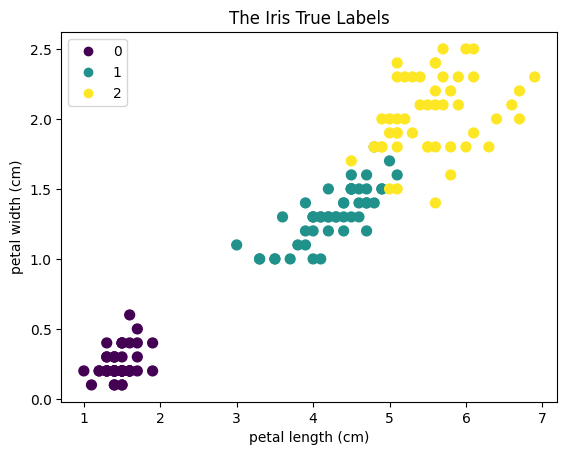

In [ ]:
plotData(data, trueLabels,fNames,0,1,"The Iris True Labels")

In [ ]:
trainData, testData, trainLabels, testLabels = train_test_split(
    data, trueLabels, test_size = 0.40,stratify=trueLabels)

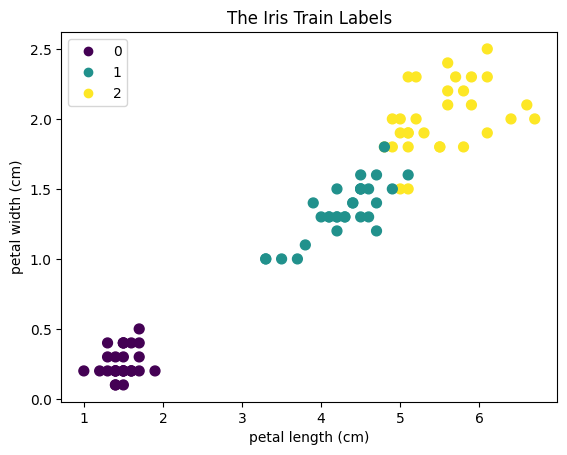

In [ ]:
plotData(trainData, trainLabels,fNames,0,1,"The Iris Train Labels")

In [ ]:
# generate a decision tree

Dtree = tree.DecisionTreeClassifier(max_depth=3)
Dtree.fit(trainData, trainLabels)

DecisionTreeClassifier(max_depth=3)

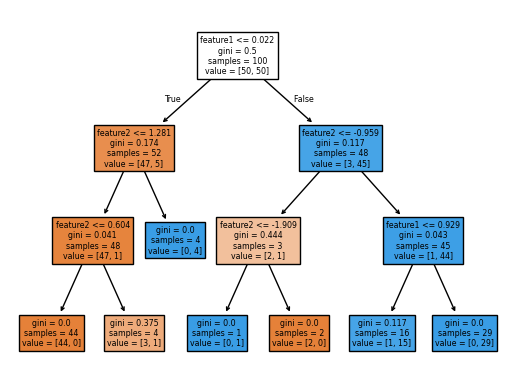

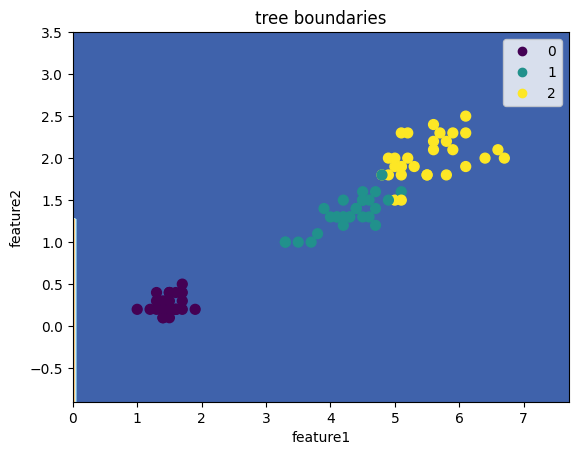

In [ ]:
plotTree(Dtree,trainData,trainLabels)

In [ ]:
# show a sample prediction
index = 50
sample = testData[index,:].reshape(1,-1)
DtreePredLabel = Dtree.predict(sample)[0]
trueLabel = testLabels[index]
print("sample"+str(index)+"["+str(sample[0][0])+
      ","+str(sample[0][1]) +"] true=" + str(trueLabel) +
      " predicted ="+str(DtreePredLabel))

sample50[5.7,2.1] true=2 predicted =2


In [ ]:
# predict labels
DtreePredLabels = Dtree.predict(testData)

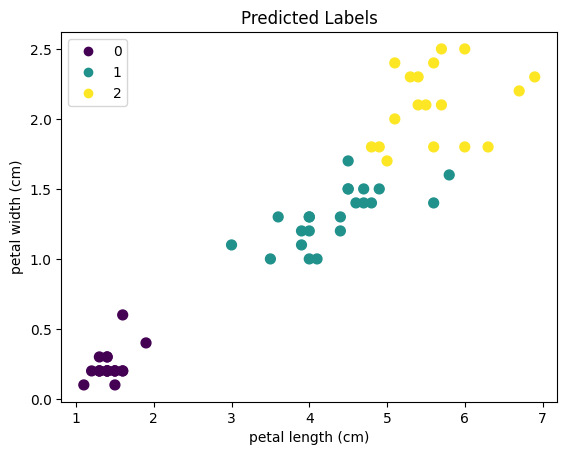

In [ ]:
plotData(testData,DtreePredLabels,fNames,0,1,"Predicted Labels")

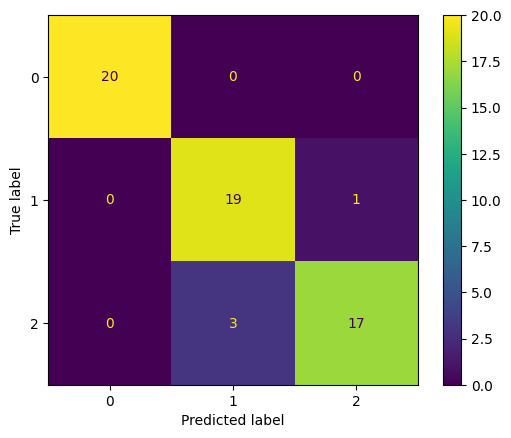

In [ ]:
# generate confusion matrix
cm = confusion_matrix(testLabels, DtreePredLabels)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [ ]:
from sklearn.tree import export_text
#Pick two samples from the test set (let's use index 5 and index 25)
sample_indices = [5, 25]
print("\n--- Test Samples ---")
for idx in sample_indices:
    feat_values = testData[idx]
    true_lbl = testLabels[idx]
    pred_lbl = Dtree.predict([feat_values])[0]
    print(f"Sample {idx}: Features (Petal Length, Petal Width) = {feat_values}")
    print(f"          True Label = {true_lbl}, Predicted = {pred_lbl}\n")


--- Test Samples ---
Sample 5: Features (Petal Length, Petal Width) = [5.6 2.4]
          True Label = 2, Predicted = 2

Sample 25: Features (Petal Length, Petal Width) = [1.2 0.2]
          True Label = 0, Predicted = 0



In [ ]:
centers = ([-1,-1],[1,1])
std = (1,1)
randomData, randomLabels = make_blobs(
    n_samples=100, n_features = 2, centers=centers, cluster_std = std)

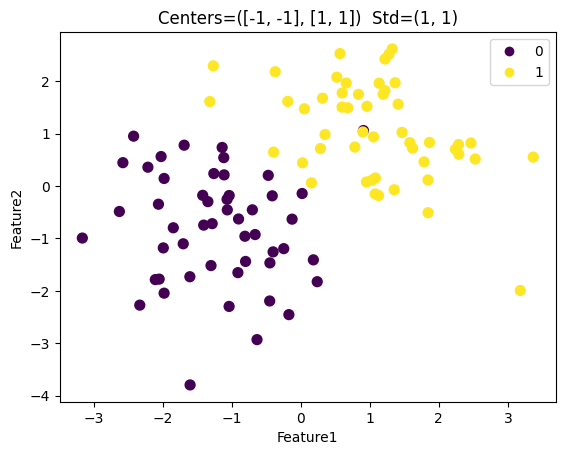

In [ ]:
randomTitle =  "Centers="+str(centers)+"  Std=" + str(std)
fNames = ["Feature1","Feature2"]
plotData(randomData,randomLabels,fNames,0,1,randomTitle)

In [ ]:
Dtree = tree.DecisionTreeClassifier(max_depth=3)
Dtree.fit(randomData, randomLabels)

DecisionTreeClassifier(max_depth=3)

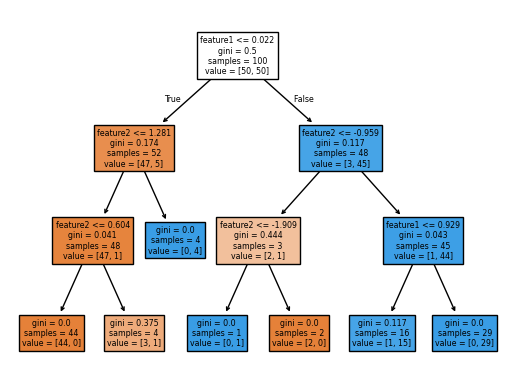

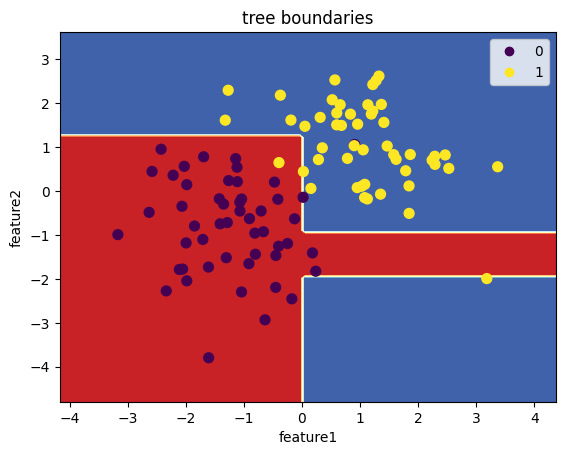

In [ ]:
plotTree(Dtree,randomData,randomLabels)